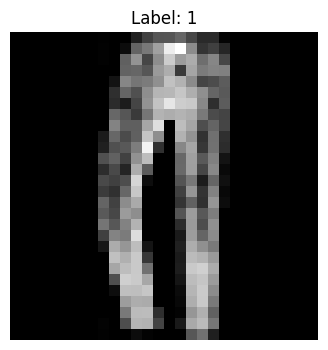

Epoch 0 | Train Loss: 1.9330 | Train Acc: 0.2697 | Val Loss: 1.1679 | Val Acc: 0.6115
Epoch 1 | Train Loss: 1.1779 | Train Acc: 0.5352 | Val Loss: 0.8244 | Val Acc: 0.6971
Epoch 2 | Train Loss: 0.9315 | Train Acc: 0.6424 | Val Loss: 0.6947 | Val Acc: 0.7434
Epoch 3 | Train Loss: 0.8199 | Train Acc: 0.6923 | Val Loss: 0.6285 | Val Acc: 0.7622
Epoch 4 | Train Loss: 0.7536 | Train Acc: 0.7198 | Val Loss: 0.5886 | Val Acc: 0.7702
Epoch 5 | Train Loss: 0.7023 | Train Acc: 0.7412 | Val Loss: 0.5558 | Val Acc: 0.7871
Epoch 6 | Train Loss: 0.6680 | Train Acc: 0.7573 | Val Loss: 0.5329 | Val Acc: 0.7932
Epoch 7 | Train Loss: 0.6414 | Train Acc: 0.7685 | Val Loss: 0.5112 | Val Acc: 0.8127
Epoch 8 | Train Loss: 0.6206 | Train Acc: 0.7813 | Val Loss: 0.4927 | Val Acc: 0.8186
Epoch 9 | Train Loss: 0.5985 | Train Acc: 0.7904 | Val Loss: 0.4738 | Val Acc: 0.8319
Epoch 10 | Train Loss: 0.5791 | Train Acc: 0.7983 | Val Loss: 0.4594 | Val Acc: 0.8358
Epoch 11 | Train Loss: 0.5629 | Train Acc: 0.8087 | V

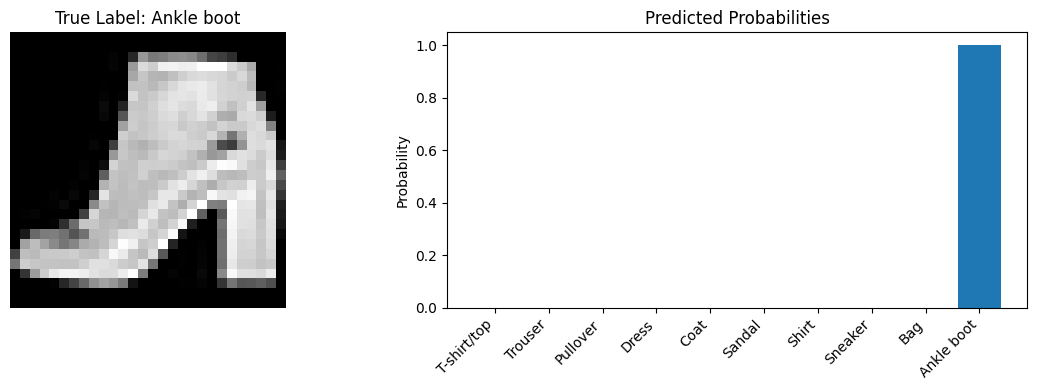

Test Loss: 0.343.. Test Accuracy: 0.886

EVALUATION METRICS
Test Accuracy: 0.8861
Test Loss:     0.3428
Precision:     0.8859
Recall:        0.8862
F1-Score:      0.8857


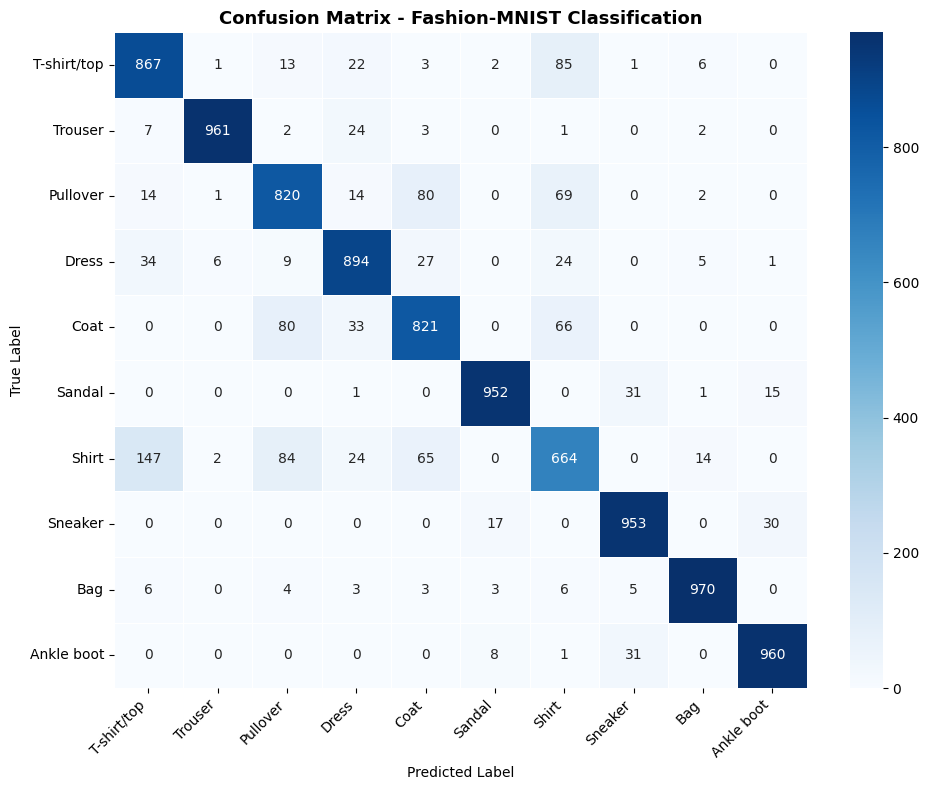

In [24]:
import torch
from torchvision import datasets, transforms
from torch import nn
from torch import optim
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    precision_score, recall_score, f1_score, accuracy_score
)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Define a transform to normalize the data
transform = transforms.Compose([transforms.ToTensor(),
                                transforms.Normalize((0.5,), (0.5,))])

# Download and load the training data
trainset_full = datasets.FashionMNIST('~/.pytorch/F_MNIST_data/', download=True, train=True, transform=transform)

train_set, validation_set = train_test_split(trainset_full, test_size=0.2, random_state=42)

trainloader = torch.utils.data.DataLoader(train_set, batch_size=64, shuffle=True)
validationloader = torch.utils.data.DataLoader(validation_set, batch_size=64, shuffle=True)

# Download and load the test data
testset = datasets.FashionMNIST('~/.pytorch/F_MNIST_data/', download=True, train=False, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=True)

# Display sample image
image, label = next(iter(trainloader))
plt.figure(figsize=(4, 4))
plt.imshow(image[0].squeeze(), cmap='gray')
plt.title(f'Label: {label[0].item()}')
plt.axis('off')
plt.show()

# Define the MLP model
model = nn.Sequential(
    nn.Linear(784, 256),
    nn.ReLU(),
    nn.Dropout(p=0.5),

    nn.Linear(256, 128),
    nn.ReLU(),
    nn.Dropout(p=0.5),

    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Dropout(p=0.5),

    nn.Linear(64, 10),
    nn.LogSoftmax(dim=1)
)

criterion = nn.NLLLoss()
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9, weight_decay=1e-4)

# Training loop with early stopping
epochs = 100
patience = 10
counter = 0
best_loss = float('inf')
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

CLASS_NAMES = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

for epo in range(epochs):
    # Training phase
    model.train()
    running_loss = 0
    running_correct = 0
    total_train = 0
    
    for images, labels in trainloader:
        images = images.view(images.shape[0], -1)
        optimizer.zero_grad()
        output = model(images)
        loss = criterion(output, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        
        _, preds = torch.max(output, 1)
        running_correct += (preds == labels).sum().item()
        total_train += labels.size(0)

    average_training_loss = running_loss / len(trainloader)
    train_acc = running_correct / total_train

    # Validation phase
    model.eval()
    validation_loss = 0
    val_correct = 0
    total_val = 0
    
    with torch.no_grad():
        for val_images, val_labels in validationloader:
            val_images = val_images.view(val_images.shape[0], -1)
            val_output = model(val_images)
            v_loss = criterion(val_output, val_labels)
            validation_loss += v_loss.item()
            
            _, preds = torch.max(val_output, 1)
            val_correct += (preds == val_labels).sum().item()
            total_val += val_labels.size(0)

    average_validation_loss = validation_loss / len(validationloader)
    val_acc = val_correct / total_val

    print(f"Epoch {epo} | Train Loss: {average_training_loss:.4f} | Train Acc: {train_acc:.4f} | Val Loss: {average_validation_loss:.4f} | Val Acc: {val_acc:.4f}")
    
    train_losses.append(average_training_loss)
    val_losses.append(average_validation_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)
    
    if average_validation_loss < best_loss:
        best_loss = average_validation_loss
        counter = 0
        torch.save(model.state_dict(), 'best_model.pth')
    else:
        counter += 1
        print(f"EarlyStopping counter: {counter} out of {patience}")

    if counter >= patience:
        print("Early Stopping triggered. Loading best model...")
        model.load_state_dict(torch.load('best_model.pth'))
        break

# Load best model
model.load_state_dict(torch.load('best_model.pth'))

# Display sample prediction
dataiter = iter(testloader)
images, labels = next(dataiter)

img = images[0]
img_flat = img.view(1, 784)
ps = torch.exp(model.forward(img_flat))

# Plot the prediction
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.imshow(img.squeeze(), cmap='gray')
ax1.set_title(f'True Label: {CLASS_NAMES[labels[0].item()]}')
ax1.axis('off')

ax2.bar(range(10), ps.squeeze().detach().numpy())
ax2.set_xticks(range(10))
ax2.set_xticklabels(CLASS_NAMES, rotation=45, ha='right')
ax2.set_title('Predicted Probabilities')
ax2.set_ylabel('Probability')

plt.tight_layout()
plt.show()

# Evaluate on test set and collect predictions
test_loss = 0
accuracy = 0
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in testloader:
        images = images.view(images.shape[0], -1)

        log_ps = model(images)
        test_loss += criterion(log_ps, labels).item()

        ps = torch.exp(log_ps)
        _, top_class = ps.topk(1, dim=1)
        
        all_preds.extend(top_class.cpu().numpy().flatten())
        all_labels.extend(labels.numpy())

        equals = top_class == labels.view(*top_class.shape)
        accuracy += torch.mean(equals.type(torch.FloatTensor)).item()

test_loss /= len(testloader)
accuracy /= len(testloader)

print(f"Test Loss: {test_loss:.3f}.. Test Accuracy: {accuracy:.3f}")

# Calculate evaluation metrics
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

precision = precision_score(all_labels, all_preds, average='macro')
recall = recall_score(all_labels, all_preds, average='macro')
f1 = f1_score(all_labels, all_preds, average='macro')

print("\n" + "="*50)
print("EVALUATION METRICS")
print("="*50)
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Loss:     {test_loss:.4f}")
print(f"Precision:     {precision:.4f}")
print(f"Recall:        {recall:.4f}")
print(f"F1-Score:      {f1:.4f}")
print("="*50)

# Confusion Matrix Graph
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            linewidths=0.5)
plt.title('Confusion Matrix - Fashion-MNIST Classification', fontsize=13, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

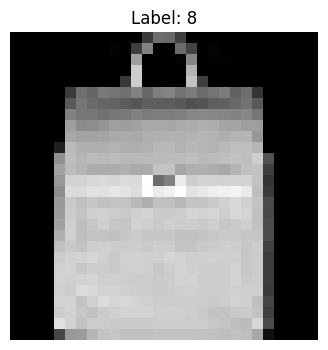

Epoch 0 | Train Loss: 1.9145 | Train Acc: 0.2666 | Val Loss: 1.2004 | Val Acc: 0.5338
Epoch 1 | Train Loss: 1.2002 | Train Acc: 0.5185 | Val Loss: 0.8369 | Val Acc: 0.6871
Epoch 2 | Train Loss: 0.9448 | Train Acc: 0.6388 | Val Loss: 0.6876 | Val Acc: 0.7296
Epoch 3 | Train Loss: 0.8138 | Train Acc: 0.6928 | Val Loss: 0.6312 | Val Acc: 0.7472
Epoch 4 | Train Loss: 0.7526 | Train Acc: 0.7198 | Val Loss: 0.5899 | Val Acc: 0.7718
Epoch 5 | Train Loss: 0.7062 | Train Acc: 0.7400 | Val Loss: 0.5573 | Val Acc: 0.7846
Epoch 6 | Train Loss: 0.6700 | Train Acc: 0.7591 | Val Loss: 0.5282 | Val Acc: 0.8043
Epoch 7 | Train Loss: 0.6399 | Train Acc: 0.7726 | Val Loss: 0.5064 | Val Acc: 0.8195
Epoch 8 | Train Loss: 0.6176 | Train Acc: 0.7844 | Val Loss: 0.4840 | Val Acc: 0.8242
Epoch 9 | Train Loss: 0.5933 | Train Acc: 0.7957 | Val Loss: 0.4689 | Val Acc: 0.8298
Epoch 10 | Train Loss: 0.5707 | Train Acc: 0.8047 | Val Loss: 0.4565 | Val Acc: 0.8336
Epoch 11 | Train Loss: 0.5536 | Train Acc: 0.8127 | V

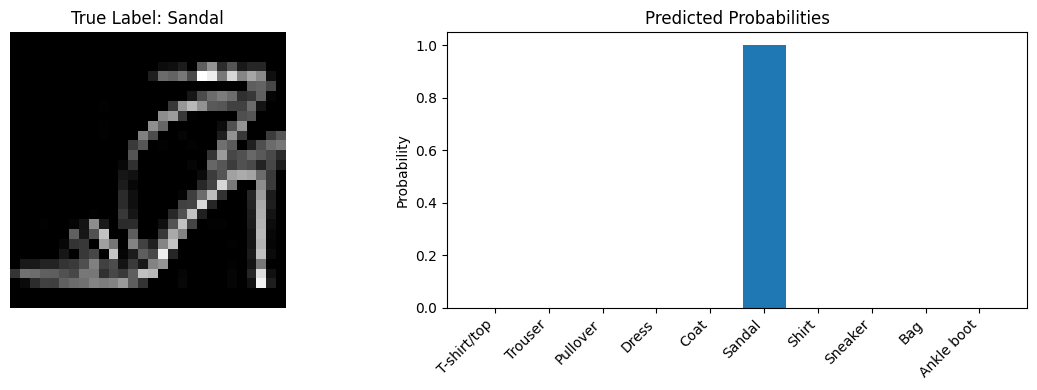

Test Loss: 0.344.. Test Accuracy: 0.885


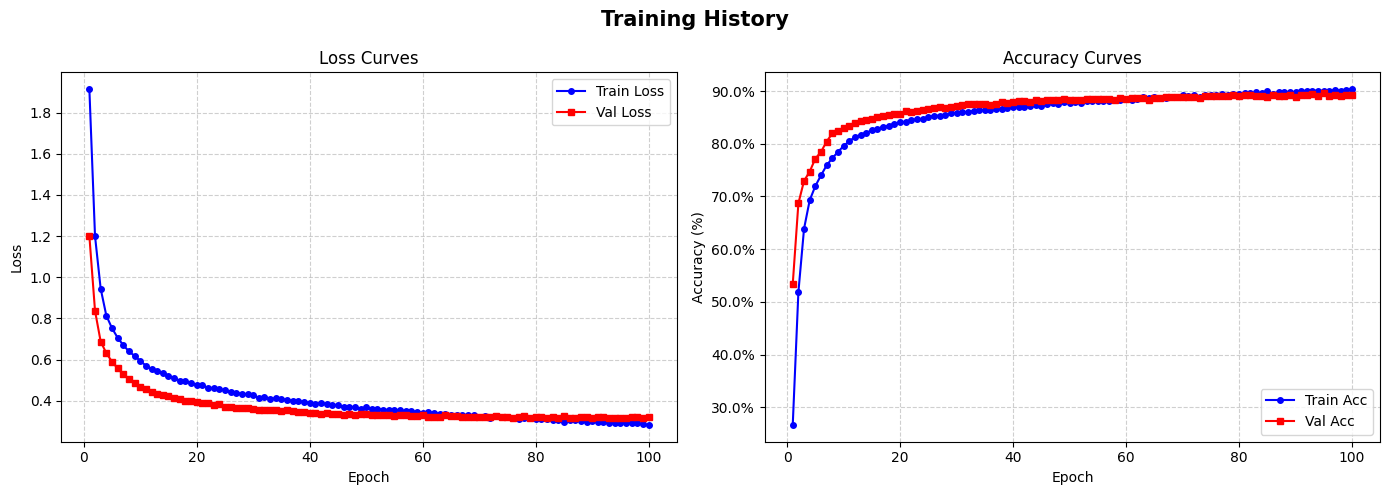


EVALUATION METRICS
Test Accuracy: 0.8854
Test Loss:     0.3439
Precision:     0.8845
Recall:        0.8852
F1-Score:      0.8842


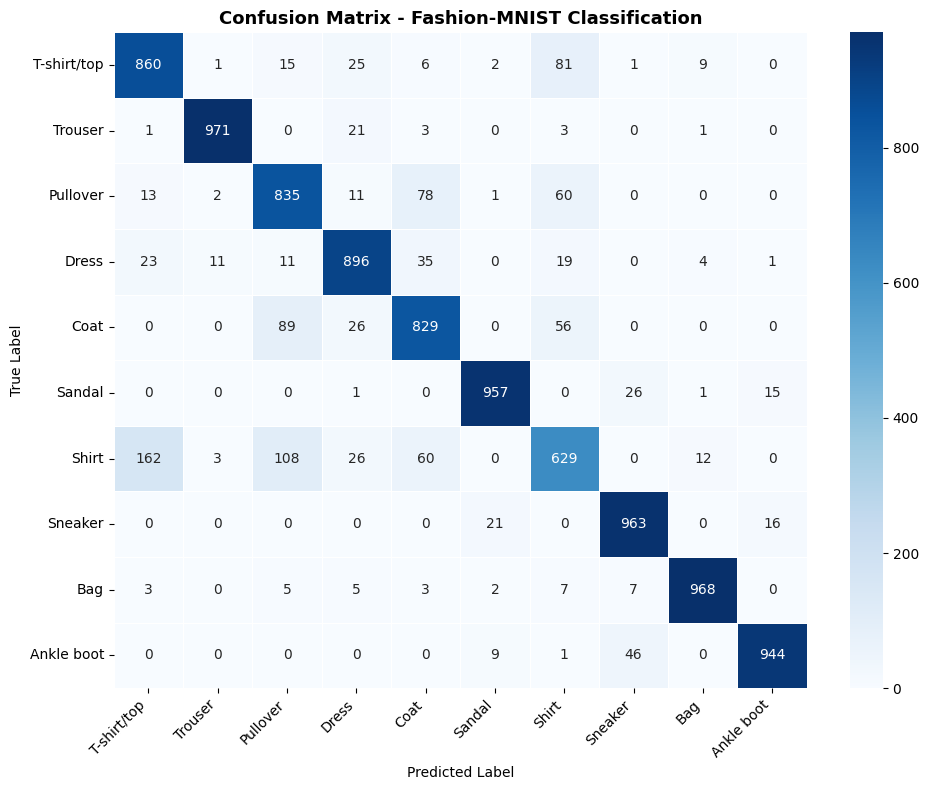


PER-CLASS CLASSIFICATION METRICS
Class           Precision    Recall       F1-Score     Support   
----------------------------------------------------------------------
T-shirt/top     0.8098       0.8600       0.8341       1000      
Trouser         0.9828       0.9710       0.9769       1000      
Pullover        0.7855       0.8350       0.8095       1000      
Dress           0.8863       0.8960       0.8911       1000      
Coat            0.8176       0.8290       0.8232       1000      
Sandal          0.9647       0.9570       0.9608       1000      
Shirt           0.7348       0.6290       0.6778       1000      
Sneaker         0.9233       0.9630       0.9427       1000      
Bag             0.9729       0.9680       0.9704       1000      
Ankle boot      0.9672       0.9440       0.9555       1000      

Final Test Accuracy: 88.54%


In [25]:
import torch
from torchvision import datasets, transforms
from torch import nn
from torch import optim
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    precision_score, recall_score, f1_score, accuracy_score
)
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np

# Define a transform to normalize the data
transform = transforms.Compose([transforms.ToTensor(),
                                transforms.Normalize((0.5,), (0.5,))])

# Download and load the training data
trainset_full = datasets.FashionMNIST('~/.pytorch/F_MNIST_data/', download=True, train=True, transform=transform)

train_set, validation_set = train_test_split(trainset_full, test_size=0.2, random_state=42)

trainloader = torch.utils.data.DataLoader(train_set, batch_size=64, shuffle=True)
validationloader = torch.utils.data.DataLoader(validation_set, batch_size=64, shuffle=True)

# Download and load the test data
testset = datasets.FashionMNIST('~/.pytorch/F_MNIST_data/', download=True, train=False, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=True)

# Display sample image
image, label = next(iter(trainloader))
plt.figure(figsize=(4, 4))
plt.imshow(image[0].squeeze(), cmap='gray')
plt.title(f'Label: {label[0].item()}')
plt.axis('off')
plt.show()

# Define the MLP model
model = nn.Sequential(
    nn.Linear(784, 256),
    nn.ReLU(),
    nn.Dropout(p=0.5),

    nn.Linear(256, 128),
    nn.ReLU(),
    nn.Dropout(p=0.5),

    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Dropout(p=0.5),

    nn.Linear(64, 10),
    nn.LogSoftmax(dim=1)
)

criterion = nn.NLLLoss()
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9, weight_decay=1e-4)

# Training loop with early stopping
epochs = 100
patience = 10
counter = 0
best_loss = float('inf')
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

CLASS_NAMES = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

for epo in range(epochs):
    # Training phase
    model.train()
    running_loss = 0
    running_correct = 0
    total_train = 0
    
    for images, labels in trainloader:
        images = images.view(images.shape[0], -1)
        optimizer.zero_grad()
        output = model(images)
        loss = criterion(output, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        
        _, preds = torch.max(output, 1)
        running_correct += (preds == labels).sum().item()
        total_train += labels.size(0)

    average_training_loss = running_loss / len(trainloader)
    train_acc = running_correct / total_train

    # Validation phase
    model.eval()
    validation_loss = 0
    val_correct = 0
    total_val = 0
    
    with torch.no_grad():
        for val_images, val_labels in validationloader:
            val_images = val_images.view(val_images.shape[0], -1)
            val_output = model(val_images)
            v_loss = criterion(val_output, val_labels)
            validation_loss += v_loss.item()
            
            _, preds = torch.max(val_output, 1)
            val_correct += (preds == val_labels).sum().item()
            total_val += val_labels.size(0)

    average_validation_loss = validation_loss / len(validationloader)
    val_acc = val_correct / total_val

    print(f"Epoch {epo} | Train Loss: {average_training_loss:.4f} | Train Acc: {train_acc:.4f} | Val Loss: {average_validation_loss:.4f} | Val Acc: {val_acc:.4f}")
    
    train_losses.append(average_training_loss)
    val_losses.append(average_validation_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)
    
    if average_validation_loss < best_loss:
        best_loss = average_validation_loss
        counter = 0
        torch.save(model.state_dict(), 'best_model.pth')
    else:
        counter += 1
        print(f"EarlyStopping counter: {counter} out of {patience}")

    if counter >= patience:
        print("Early Stopping triggered. Loading best model...")
        model.load_state_dict(torch.load('best_model.pth'))
        break

# Load best model
model.load_state_dict(torch.load('best_model.pth'))

# Display sample prediction
dataiter = iter(testloader)
images, labels = next(dataiter)

img = images[0]
img_flat = img.view(1, 784)
ps = torch.exp(model.forward(img_flat))

# Plot the prediction
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.imshow(img.squeeze(), cmap='gray')
ax1.set_title(f'True Label: {CLASS_NAMES[labels[0].item()]}')
ax1.axis('off')

ax2.bar(range(10), ps.squeeze().detach().numpy())
ax2.set_xticks(range(10))
ax2.set_xticklabels(CLASS_NAMES, rotation=45, ha='right')
ax2.set_title('Predicted Probabilities')
ax2.set_ylabel('Probability')

plt.tight_layout()
plt.show()

# Evaluate on test set and collect predictions
test_loss = 0
accuracy = 0
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in testloader:
        images = images.view(images.shape[0], -1)

        log_ps = model(images)
        test_loss += criterion(log_ps, labels).item()

        ps = torch.exp(log_ps)
        _, top_class = ps.topk(1, dim=1)
        
        all_preds.extend(top_class.cpu().numpy().flatten())
        all_labels.extend(labels.numpy())

        equals = top_class == labels.view(*top_class.shape)
        accuracy += torch.mean(equals.type(torch.FloatTensor)).item()

test_loss /= len(testloader)
accuracy /= len(testloader)

print(f"Test Loss: {test_loss:.3f}.. Test Accuracy: {accuracy:.3f}")

# ============================================
# TRAINING VS VALIDATION GRAPHS
# ============================================

epochs_range = range(1, len(train_losses) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Training History', fontsize=15, fontweight='bold')

# Loss Curves
ax = axes[0]
ax.plot(epochs_range, train_losses, 'b-o', markersize=4, label='Train Loss')
ax.plot(epochs_range, val_losses,   'r-s', markersize=4, label='Val Loss')
ax.set_title('Loss Curves')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.6)

# Accuracy Curves
ax = axes[1]
ax.plot(epochs_range, [a * 100 for a in train_accuracies], 'b-o', markersize=4, label='Train Acc')
ax.plot(epochs_range, [a * 100 for a in val_accuracies],   'r-s', markersize=4, label='Val Acc')
ax.set_title('Accuracy Curves')
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy (%)')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))
ax.legend()
ax.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# ============================================
# EVALUATION METRICS
# ============================================

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

precision = precision_score(all_labels, all_preds, average='macro')
recall = recall_score(all_labels, all_preds, average='macro')
f1 = f1_score(all_labels, all_preds, average='macro')

print("\n" + "="*50)
print("EVALUATION METRICS")
print("="*50)
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Loss:     {test_loss:.4f}")
print(f"Precision:     {precision:.4f}")
print(f"Recall:        {recall:.4f}")
print(f"F1-Score:      {f1:.4f}")
print("="*50)

# ============================================
# CONFUSION MATRIX GRAPH
# ============================================

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            linewidths=0.5)
plt.title('Confusion Matrix - Fashion-MNIST Classification', fontsize=13, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# ============================================
# PER-CLASS METRICS TABLE
# ============================================

print("\n" + "="*70)
print("PER-CLASS CLASSIFICATION METRICS")
print("="*70)
print(f"{'Class':<15} {'Precision':<12} {'Recall':<12} {'F1-Score':<12} {'Support':<10}")
print("-"*70)

for i, class_name in enumerate(CLASS_NAMES):
    tp = cm[i, i]
    fp = cm[:, i].sum() - tp
    fn = cm[i, :].sum() - tp
    
    precision_i = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall_i = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1_i = 2 * precision_i * recall_i / (precision_i + recall_i) if (precision_i + recall_i) > 0 else 0
    support = cm[i, :].sum()
    
    print(f"{class_name:<15} {precision_i:<12.4f} {recall_i:<12.4f} {f1_i:<12.4f} {support:<10.0f}")

print("="*70)

print(f"\nFinal Test Accuracy: {accuracy*100:.2f}%")